**Nombre:** Manuel Ramíreza Galván

**Actividad:** 1

# <font color=blue>Detección de objetos con IA</font>


**Objetivos:**
Implementar un sistema de reconocimiento de patrones, objetos, etc. aplicandos algoritmos de Inteligencia Artificial.

## <font color=green> Ejercicio 1:  Importar bibliotecas necesarias</font>

In [34]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

In [35]:
#librerias de entrenamiento y clasificacion utilizadas para aplicar Inteligencia Artificial
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

## <font color=green> Ejercicio 2: Funcion para encontrar Momentos y Area de figuras geométricas</font>

**Objetivo:** Calcular los momentos de hu y areas de cada contorno para clasificación de formas.

**Pasos:**
1. Calcula los momentos de cada contorno con `cv2.moments()`.
2. Extrae los Momentos de Hu con `cv2.HuMoments()` de los momentos calculados para obtener 7 características invariantes a escala, rotación y traslación.
3. Calcula el área del contorno con `cv2.contourArea()`.
4. Delimita con un rectangulo el area utilizando `cv2.boundingRect()`
5. Calcula la relación de aspecto utilizando el ancho y alto del contorno.
6. Aproxima el contorno con `cv2.approxPolyDP()` para estimar la forma simplificada con menos vértices, usando un epsilon proporcional al perímetro.
7. Obten el total de vértices del contorno a partir de la aproximación.

In [36]:
def MomentosContornos(cnt):
    momentos = cv2.moments(cnt)
    hu = cv2.HuMoments(momentos).flatten()
    area = cv2.contourArea(cnt)
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / h if h != 0 else 0
    epsilon = 0.01 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    vertices = len(approx)
    return np.append(hu, [area, aspect_ratio, vertices])

## <font color=green> Ejercicio 3: Funcion para crear figuras</font>

**Objetivo:** Dibujar el contorno de la figura geometrica (círculo, cuadrado, rectángulo, triángulo).

**Pasos:**
1. Crea una imagen vacía de 200x200 píxeles con `np.zeros()`.
2. Define el centro fijo, un tamaño aleatorio con `random.randint()` y un color.
3. Utiliza un condicional anidado para dibujar las figura según el tipo recibido:
    * Círculo: `cv2.circle()`.
    * Cuadrado: `cv2.rectangle()`.
    * Rectángulo: `cv2.rectangle()`.
    * Triángulo: `cv2.drawContours()`
4. Aplica una rotación aleatoria con `random.randint()`.
5. Crea una matriz de rotación con `cv2.getRotationMatrix2D().` y aplica las transformaciones usando `cv2.warpAffine()`.

In [37]:
def draw_shape(shape):
    img = np.zeros((200, 200), dtype=np.uint8)

    center = (100, 100)
    size = random.randint(30, 60)
    color = 255

    if shape == 'circle':
        cv2.circle(img, center, size, color, -1)

    elif shape == 'square':
        top_left = (center[0] - size, center[1] - size)
        bottom_right = (center[0] + size, center[1] + size)
        cv2.rectangle(img, top_left, bottom_right, color, -1)

    elif shape == 'rectangle':
        w, h = size, size // 2
        top_left = (center[0] - w, center[1] - h)
        bottom_right = (center[0] + w, center[1] + h)
        cv2.rectangle(img, top_left, bottom_right, color, -1)

    elif shape == 'triangle':
        point1 = (center[0], center[1] - size)
        point2 = (center[0] - size, center[1] + size)
        point3 = (center[0] + size, center[1] + size)
        triangle_cnt = np.array([point1, point2, point3])
        cv2.drawContours(img, [triangle_cnt], 0, color, -1)

    elif shape == 'pentagon':
        points = []
        for i in range(6):
            angle = 2 * np.pi * i / 6
            x = int(center[0] + size * np.cos(angle))
            y = int(center[1] + size * np.sin(angle))
            points.append((x, y))
        pentagon_cnt = np.array(points)
        cv2.drawContours(img, [pentagon_cnt], 0, color, -1)

    angle = random.randint(0, 360)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(img, M, (200, 200))
    return img

## <font color=green> Ejercicio 4: Crear Dataset</font>

**Objetivo:** Generar nuestas bases de datos para entrenar la inteligencia artificial, con los contornos de figuras basicas.

**Pasos:**
1. Define las clases de figuras en una lista y asignarles índices numéricos mediante `enumerate()` para construir un diccionario con etiquetas numéricas `nombre-numero` y otro diccionario que genere `numero-nombre`.
2. Inicializa dos listas una de `X`(caracteristicas) y otra de `Y`(variable objetivo), estas nos ayudaran para el proceso de entrenamiento.
3. Para cada clase figura generar múltiples variaciones aleatorias se recomienda una base de datos de minimo 100 datos.
    * Genera una imagen de la figura utiliza la función `draw_shape()`.
    * Aplica un umbral binario con `cv2.threshold() `para convertir la figura a binario.
    * Detecta los contornos con `cv2.findContours()` en la imagen binaria.
    * Selecciona el contorno más grande encontrado usando `max()` y `cv2.contourArea`.
    * Extrae las características del contorno utiliza la función `MomentosContornos()`.
    * Agrega los datos obtenidos en el punto anterior al diccionario de caracteristicas (`X`) y en el diccionario de variables objetivo (`Y`) agrega el nombre de la clase.

In [38]:
clases = ['circle', 'square', 'rectangle', 'triangle']
clase_a_num = {nombre: i for i, nombre in enumerate(clases)}
num_a_clase = {i: nombre for nombre, i in clase_a_num.items()}

X = []
y = []

for clase in clases:
    for _ in range(100):
        img = draw_shape(clase)

        _, binaria = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

        contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contornos) == 0:
            continue

        contorno_principal = max(contornos, key=cv2.contourArea)

        caracteristicas = MomentosContornos(contorno_principal)

        X.append(caracteristicas)
        y.append(clase_a_num[clase])


## <font color=green> Ejercicio 5:  Entreamiento </font>

**Objetivo:** Entrenar un modelo de clasificación Random Forest utilizando las características extraídas de figuras geométricas y evaluar su precisión sobre un conjunto de prueba.

**Pasos:**


**1.** **Convertir las listas de características y etiquetas en arrays de NumPy**

Se requiere para trabajar con funciones de scikit-learn.

In [39]:
X = np.array(X)
y = np.array(y)

**2. Dividir el dataset en entrenamiento y prueba**

Usar train_test_split() para separar el 70% de los datos para entrenamiento y el 30% para prueba. Se fija random_state=42 sirve para controlar la aleatoriedad en la división de los datos en conjuntos de entrenamiento y prueba. Al establecer un valor entero para random_state, garantizamos que la división se haga de la misma manera cada vez que ejecutamos el código, lo que permite la reproducibilidad de los resultados.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**3.** **Inicializar y entrenar el modelo Random Forest**

Se usa RandomForestClassifier() con 100 árboles (n_estimators=100). El método .fit() entrena el modelo con los datos de entrenamiento

In [41]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**4. Evaluar el modelo con los datos de prueba**

Se calcula la precisión (accuracy) del modelo con `.score()`, que retorna el porcentaje de aciertos.

In [42]:
print("Precisión del modelo:", model.score(X_test, y_test))

Precisión del modelo: 1.0


## <font color=green> Ejercicio 6:  Verificación de funcionamiento con imagen </font>

**Objetivo:** Aplicar un modelo de clasificación previamente entrenado para reconocer figuras geométricas (cuadrado, triángulo, rectángulo, círculo) en una imagen real, y visualizar el resultado con etiquetas sobre cada figura.

**Pasos:**
1. Carga una imagene y convertirla a escala de grises con `cv2.cvtColor()`.
2. Aplica un umbral con `cv2.threshold()`.
3. Detecta los contornos externos de las figuras `cv2.findContours()`.
4. Ordena los contornos de izquierda a derecha con `sorted()`.
5. Clasifica cada figura detectada
    * Extrae las características con la función `MomentosContornos()`.
    * Usa un modelo entrenado para predecir su clase. Copia y pega esta linea de codigo `pred = model.predict([feats])[0]`
    * Mapea el resultado a su nombre usando `label_names`.
    * Dibuja el contorno con `cv2.drawContours()`.
    * Calcula el centroide del contorno con `cv2.moments()` y colocar el nombre de la figura con `cv2.putText()`.
6. Mostrar la imagen final a color con los contornos y las etiquetas utiliza `plt.imshow()`.

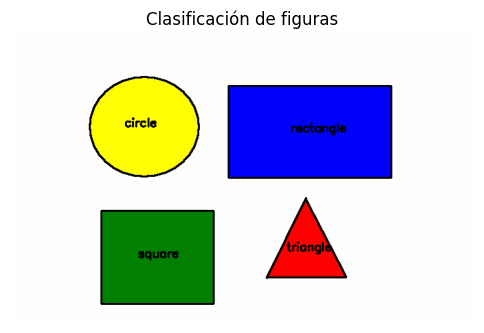

In [43]:
img_color = cv2.imread('data/figuras.png')
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

def get_x(contorno):
    x, y, w, h = cv2.boundingRect(contorno)
    return x

contours = sorted(contours, key=get_x)

for cnt in contours:
    feats = MomentosContornos(cnt)
    
    pred = model.predict([feats])[0]

    label = num_a_clase[pred]

    cv2.drawContours(img_color, [cnt], -1, (0, 0, 0), 2)
    
    M = cv2.moments(cnt)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        cv2.putText(img_color, label, (cx - 30, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.title('Clasificación de figuras')
plt.axis('off')
plt.show()
